In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


In [ ]:
import os
os.listdir('/content')


['.config', 'dog.avif', '.ipynb_checkpoints', 'sample_data']

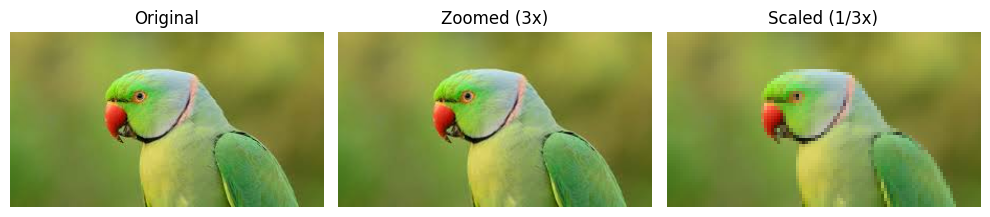

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('download.jpg')
if image is None:
    print("Image not found!")
    exit()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

scale_factor_1 = 3.0
scale_factor_2 = 1 / 3.0

height, width = image_rgb.shape[:2]

zoomed_image = cv2.resize(
    image_rgb,
    (int(width * scale_factor_1), int(height * scale_factor_1)),
    interpolation=cv2.INTER_CUBIC
)

scaled_image = cv2.resize(
    image_rgb,
    (int(width * scale_factor_2), int(height * scale_factor_2)),
    interpolation=cv2.INTER_AREA
)

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

axs[0].imshow(image_rgb)
axs[0].set_title('Original')

axs[1].imshow(zoomed_image)
axs[1].set_title('Zoomed (3x)')

axs[2].imshow(scaled_image)
axs[2].set_title('Scaled (1/3x)')

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()


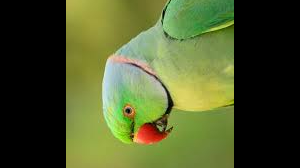

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

im = cv2.imread("download.jpg")
if im is None:
    print("Image not found!")
    exit()

h, w = im.shape[:2]
ctr = (w // 2, h // 2)

ang = 90
scl = 1.0

mat = cv2.getRotationMatrix2D(ctr, ang, scl)
rot = cv2.warpAffine(im, mat, (w, h))

cv2_imshow(rot)


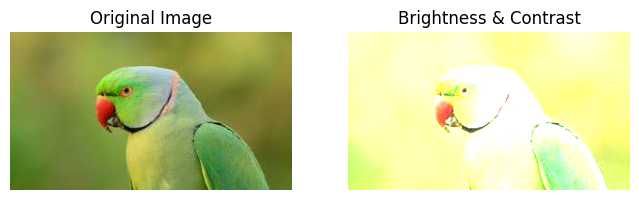

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("download.jpg")
if img is None:
    print("Image not found")
    exit()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

brightness = 60
contrast = 2.0

result = cv2.convertScaleAbs(img, alpha=contrast, beta=brightness)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Brightness & Contrast")
plt.axis("off")

plt.show()


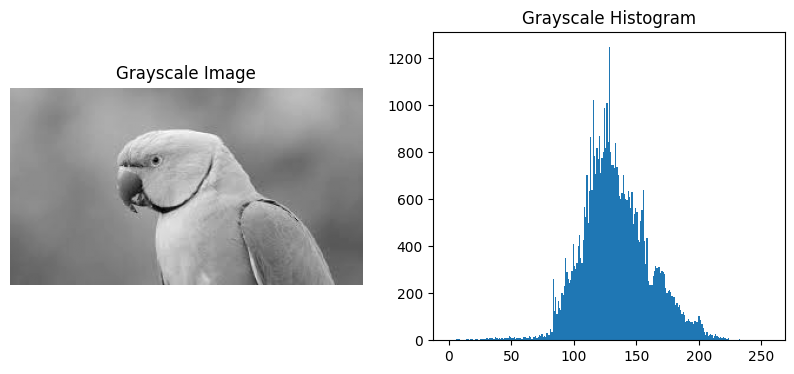

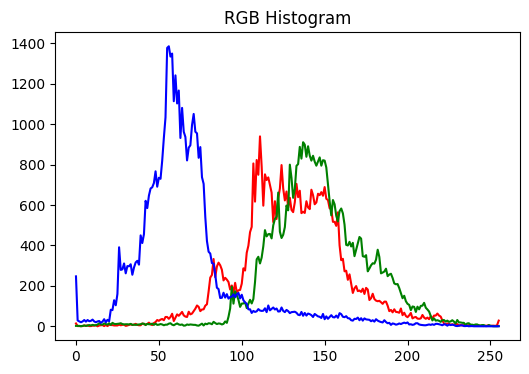

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("download.jpg")
if img is None:
    print("Image not found")
    exit()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Grayscale Histogram")

plt.show()

plt.figure(figsize=(6,4))
colors = ('r','g','b')
for i, c in enumerate(colors):
    hist = cv2.calcHist([img_rgb],[i],None,[256],[0,256])
    plt.plot(hist, color=c)

plt.title("RGB Histogram")
plt.show()


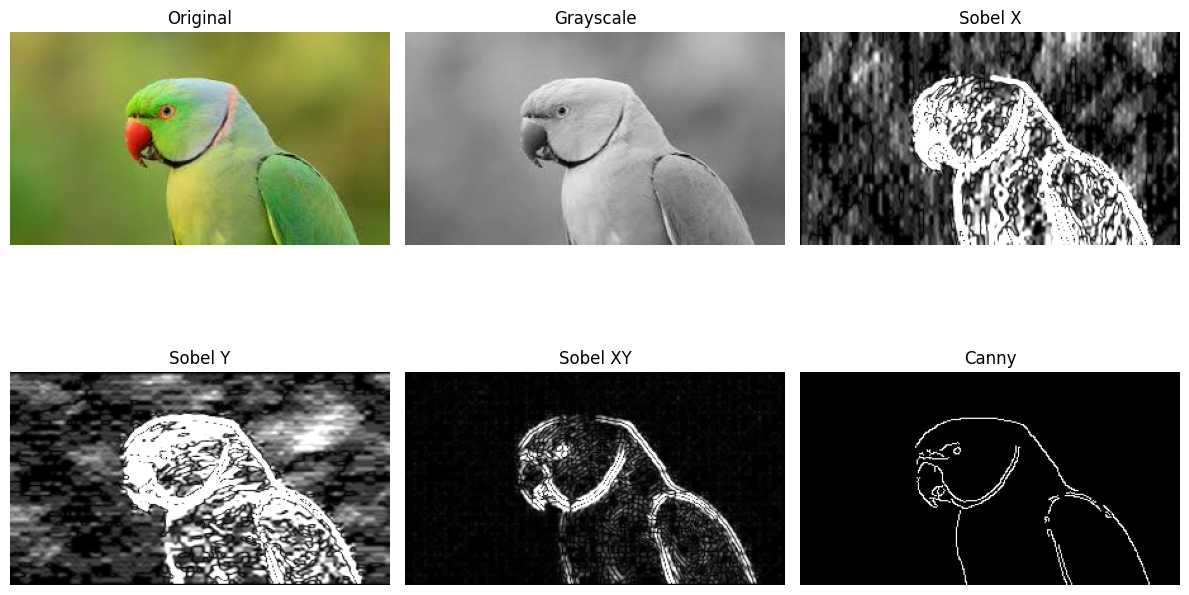

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("download.jpg")
if img is None:
    print("Image not found")
    exit()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (3,3), 0)

sobelx = cv2.convertScaleAbs(cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=5))
sobely = cv2.convertScaleAbs(cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=5))
sobelxy = cv2.convertScaleAbs(cv2.Sobel(blur, cv2.CV_64F, 1, 1, ksize=5))

edges = cv2.Canny(blur, 100, 200)

plt.figure(figsize=(12,8))

titles = ["Original", "Grayscale", "Sobel X", "Sobel Y", "Sobel XY", "Canny"]
images = [img_rgb, gray, sobelx, sobely, sobelxy, edges]

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()
